# Gradient-Based Optimization of Surrogate Model Parameters

JAXNRSur models are Equinox modules, so not only can you differentiate through the *source* parameters (mass ratio, spins) — you can also differentiate through the *model weights* themselves (the polynomial predictor coefficients). This tutorial demonstrates how to use that capability with `optax`.

> **Note:** This tutorial requires `optax`. Install it with `pip install optax` or `uv add optax`.

In [1]:
from jaxnrsur.NRHybSur3dq8 import NRHybSur3dq8Model
from jaxnrsur.NRSur7dq4 import NRSur7dq4Model
from jaxnrsur.PolyPredictor import PolyPredictor
import jax.numpy as jnp
import jax
import equinox as eqx
import optax
from jaxtyping import PyTree, Float
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)  # Use double precision

As a toy example, we will try to optimize the model parameters of the `NRSur7dq4` model to fit a target waveform generated by `NRHybSur3dq8` model. There is no inherent reason to do this, but it is a good example to show how to use the gradient with respect to the model parameters. First, let's initialize both models and make sure the are functioning correctly.

In [2]:
time = jnp.linspace(-5000, 100, 10000)
params_7d = jnp.array([1.1, 0.1, 0.4, 0.1, 0.5, 0.1, 0.3])
model_7d = NRSur7dq4Model()
hp_7d, hc_7d = model_7d(time, params_7d)

params_3d = params_7d[:3]  # Use only the first three parameters for the 3dq8 model
model_3d = NRHybSur3dq8Model()
hp_3d, hc_3d = model_3d(time, params_3d)
# Check if the models are working correctly

print("NRSur7dq4 model output shape:", hp_7d.shape, hc_7d.shape)
print("NRHybSur3dq8 model output shape:", hp_3d.shape, hc_3d.shape)

Try loading file from cache
Cache found and loading data
Try loading file from cache
Cache found and loading data
NRSur7dq4 model output shape: (10000,) (10000,)
NRHybSur3dq8 model output shape: (10000,) (10000,)


Unlike source parameters which are part of each function call, the model weights are stored as attributes of the Equinox module. To differentiate through them we use Equinox's `partition` / `combine` utilities to separate trainable arrays from static data.


In [ ]:
# Partition the model: separate PolyPredictor weights (trainable) from everything else
# (surrogate time grid, node counts, etc.) using Equinox's partition/combine utilities.


def filter_func(x):
    return isinstance(x, PolyPredictor)


def partition_model(model: NRSur7dq4Model) -> tuple[NRSur7dq4Model, PyTree, PyTree]:
    filtered_module, filter_static = eqx.partition(
        model, filter_func, is_leaf=filter_func
    )
    dynamic, static = eqx.partition(filtered_module, eqx.is_array)
    return dynamic, static, filter_static


dynamic, static, filter_static = partition_model(model_7d)

# Define the loss function to optimize the model parameters


def loss(dynamic, static, filter_static, time, params):
    model = eqx.combine(
        eqx.combine(dynamic, static), filter_static, is_leaf=filter_func
    )
    hp, hc = model(time, params)
    return jnp.mean((hp - hp_3d) ** 2 + (hc - hc_3d) ** 2)


loss_value = eqx.filter_jit(eqx.filter_value_and_grad(loss))(
    dynamic, static, filter_static, time, params_7d
)

We define the optimizer and a JIT-compiled step function. Each call to `optimize_loss` computes the gradient of the loss with respect to the trainable weights and takes one Adam step.

In [4]:
optim = optax.adam(learning_rate=1e-7)
opt_state = optim.init(
    eqx.filter(eqx.filter(model_7d, filter_func, is_leaf=filter_func), eqx.is_array)
)


@eqx.filter_jit
def optimize_loss(
    model: NRSur7dq4Model, opt_state: PyTree
) -> tuple[NRSur7dq4Model, PyTree, Float]:
    values, grads = eqx.filter_value_and_grad(loss)(
        model, static, filter_static, time, params_7d
    )
    updates, opt_state = optim.update(
        grads,
        opt_state,
        eqx.filter(eqx.filter(model, filter_func, is_leaf=filter_func), eqx.is_array),
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, values

Run the optimization loop. We keep track of the loss at each step and then compare the waveform from the updated model against the two originals.

In [5]:
losses = []
current_model = dynamic
for _ in range(500):
    current_model, opt_state, loss_value = optimize_loss(current_model, opt_state)
    losses.append(loss_value)

losses = jnp.array(losses)
combined_model = eqx.combine(
    eqx.combine(current_model, static), filter_static, is_leaf=filter_func
)
new_h = combined_model(time, params_7d)

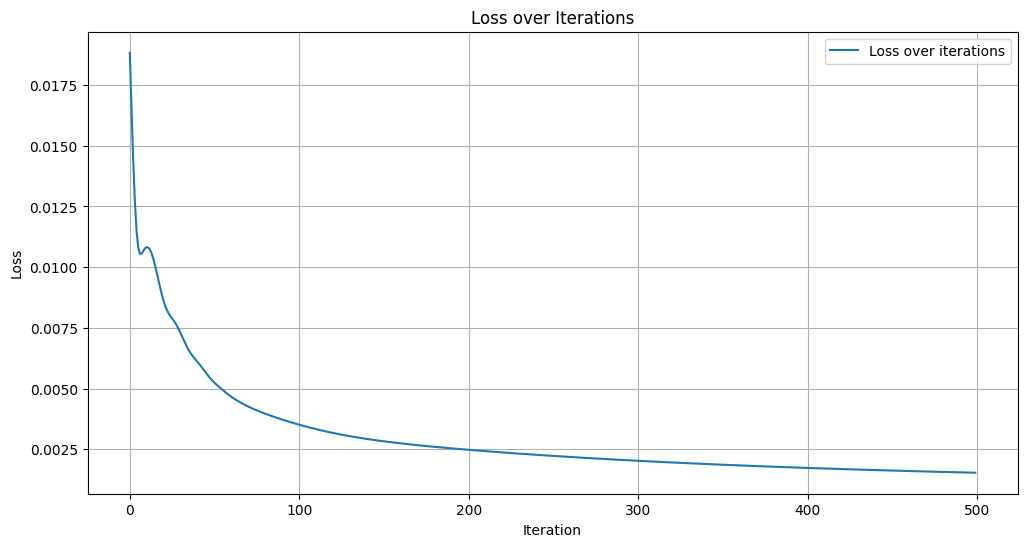

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(losses, label="Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations")
plt.legend()
plt.grid()
plt.show()

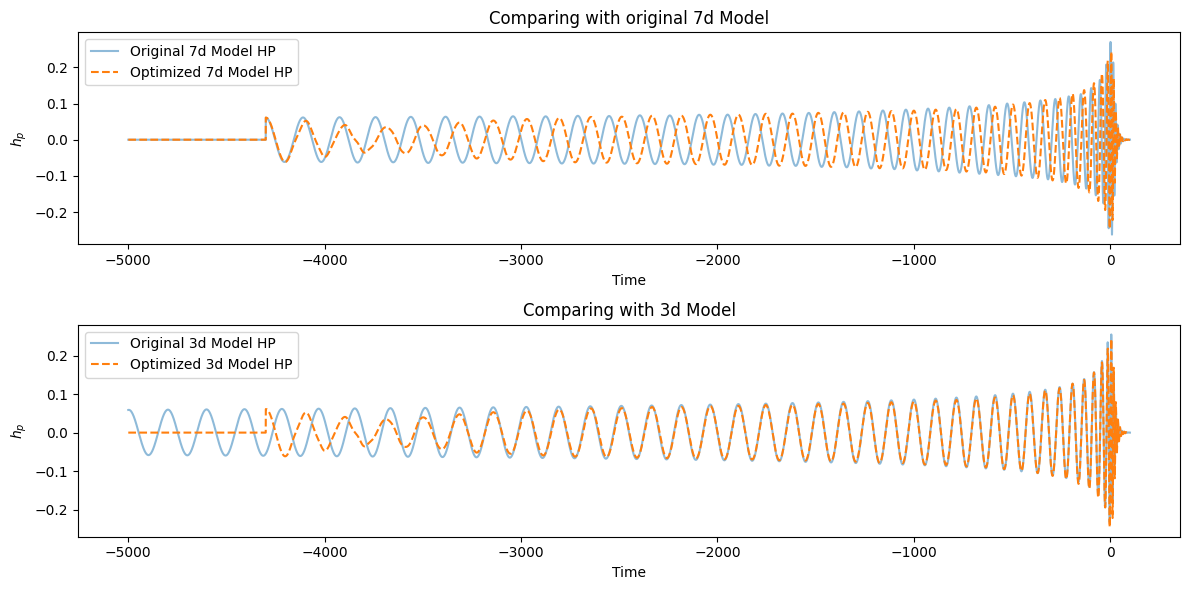

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(time, hp_7d, label="Original 7d Model HP", alpha=0.5)
ax[0].plot(time, new_h[0], label="Optimized 7d Model HP", linestyle="--")
ax[0].set_title("Comparing with original 7d Model")
ax[0].set_xlabel("Time")
ax[0].set_ylabel(r"$h_p$")
ax[0].legend()
ax[1].plot(time, hp_3d, label="Original 3d Model HP", alpha=0.5)
ax[1].plot(time, new_h[0], label="Optimized 3d Model HP", linestyle="--")
ax[1].set_title("Comparing with 3d Model")
ax[1].set_xlabel("Time")
ax[1].set_ylabel(r"$h_p$")
ax[1].legend()
plt.tight_layout()
plt.show()

This is just a crude example to show how one can change the model parameters instead of producing any physically meaningful results, but one can see that the model is indeed updated.